In [15]:
#loading libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [16]:
df = pd.read_csv("ev_range_prediction_dataset.csv")

In [17]:
df.head()

,vehicle_id,battery_capacity_kwh,base_range_km,efficiency_score_wh_per_km,acceleration_0_100_s,drivetrain,price_usd,release_year,market_region,safety_rating,long_range_capable,speed_kmh,terrain_grade_pct,ambient_temp_c,hvac_level,payload_kg,trip_distance_km,adjusted_range_km,energy_consumed_kwh,range_anxiety_flag
0,EV0001,99.7,558.9,178.4,10.46,RWD,72977.0,2018,Asia,3,1,59.8,-0.49,9.3,0,349.0,24.8,423.3,5.84,0
1,EV0001,99.7,558.9,178.4,10.46,RWD,72977.0,2018,Asia,3,1,109.4,3.98,16.1,0,357.0,140.2,246.2,56.77,0
2,EV0001,99.7,558.9,178.4,10.46,RWD,72977.0,2018,Asia,3,1,55.0,4.24,37.1,0,175.0,318.8,416.7,76.28,0
3,EV0001,99.7,558.9,178.4,10.46,RWD,72977.0,2018,Asia,3,1,107.9,4.10,42.0,1,240.0,251.0,203.8,122.79,1
4,EV0001,99.7,558.9,178.4,10.46,RWD,72977.0,2018,Asia,3,1,86.1,0.16,16.0,2,144.0,301.6,248.6,120.96,1


In [18]:
df.tail()

,vehicle_id,battery_capacity_kwh,base_range_km,efficiency_score_wh_per_km,acceleration_0_100_s,drivetrain,price_usd,release_year,market_region,safety_rating,long_range_capable,speed_kmh,terrain_grade_pct,ambient_temp_c,hvac_level,payload_kg,trip_distance_km,adjusted_range_km,energy_consumed_kwh,range_anxiety_flag
4795,EV0120,86.5,660.8,130.9,8.4,FWD,72228.0,2017,North America,5,1,40.0,1.09,32.3,0,146.0,28.3,486.9,5.03,0
4796,EV0120,86.5,660.8,130.9,8.4,FWD,72228.0,2017,North America,5,1,72.7,1.02,23.1,1,333.0,285.5,313.6,78.75,0
4797,EV0120,86.5,660.8,130.9,8.4,FWD,72228.0,2017,North America,5,1,107.4,-3.89,14.9,1,125.0,383.2,335.0,98.95,1
4798,EV0120,86.5,660.8,130.9,8.4,FWD,72228.0,2017,North America,5,1,108.1,-2.37,16.7,0,68.0,181.9,360.0,43.71,0
4799,EV0120,86.5,660.8,130.9,8.4,FWD,72228.0,2017,North America,5,1,114.8,0.20,27.7,0,387.0,8.9,323.4,2.38,0


In [19]:
df.shape

(4800, 20)

In [20]:
df.columns

Index(['vehicle_id', 'battery_capacity_kwh', 'base_range_km',
       'efficiency_score_wh_per_km', 'acceleration_0_100_s', 'drivetrain',
       'price_usd', 'release_year', 'market_region', 'safety_rating',
       'long_range_capable', 'speed_kmh', 'terrain_grade_pct',
       'ambient_temp_c', 'hvac_level', 'payload_kg', 'trip_distance_km',
       'adjusted_range_km', 'energy_consumed_kwh', 'range_anxiety_flag'],
      dtype='str')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   vehicle_id                  4800 non-null   str    
 1   battery_capacity_kwh        4800 non-null   float64
 2   base_range_km               4800 non-null   float64
 3   efficiency_score_wh_per_km  4800 non-null   float64
 4   acceleration_0_100_s        4800 non-null   float64
 5   drivetrain                  4800 non-null   str    
 6   price_usd                   4800 non-null   float64
 7   release_year                4800 non-null   int64  
 8   market_region               4800 non-null   str    
 9   safety_rating               4800 non-null   int64  
 10  long_range_capable          4800 non-null   int64  
 11  speed_kmh                   4800 non-null   float64
 12  terrain_grade_pct           4800 non-null   float64
 13  ambient_temp_c              4800 non-null   

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_capacity_kwh,4800.0,74.883333,24.539421,30.70,54.3500,72.350,95.5000,117.80
base_range_km,4800.0,456.155833,166.070392,168.50,317.2500,450.650,573.9250,851.50
efficiency_score_wh_per_km,4800.0,168.748333,29.990597,121.40,139.9000,169.250,195.4000,219.20
acceleration_0_100_s,4800.0,7.461917,2.519629,3.19,5.2050,7.665,9.9125,11.82
price_usd,4800.0,69723.308333,14485.948413,34079.00,60012.5000,69614.500,77660.0000,102438.00
release_year,4800.0,2020.641667,2.729130,2016.00,2018.7500,2021.000,2023.0000,2025.00
safety_rating,4800.0,3.825000,0.823316,3.00,3.0000,4.000,5.0000,5.00
long_range_capable,4800.0,0.683333,0.465225,0.00,0.0000,1.000,1.0000,1.00
speed_kmh,4800.0,74.959708,31.525977,20.10,47.7750,74.800,102.4000,130.00
terrain_grade_pct,4800.0,0.015315,3.978725,-10.00,-2.6500,0.030,2.6700,10.00


In [28]:
df.isnull().sum()

vehicle_id                    0
battery_capacity_kwh          0
base_range_km                 0
efficiency_score_wh_per_km    0
acceleration_0_100_s          0
drivetrain                    0
price_usd                     0
release_year                  0
market_region                 0
safety_rating                 0
long_range_capable            0
speed_kmh                     0
terrain_grade_pct             0
ambient_temp_c                0
hvac_level                    0
payload_kg                    0
trip_distance_km              0
adjusted_range_km             0
energy_consumed_kwh           0
range_anxiety_flag            0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
y = df["adjusted_range_km"]

In [32]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object","str"]).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['battery_capacity_kwh', 'base_range_km', 'efficiency_score_wh_per_km',
       'acceleration_0_100_s', 'price_usd', 'release_year', 'safety_rating',
       'long_range_capable', 'speed_kmh', 'terrain_grade_pct',
       'ambient_temp_c', 'hvac_level', 'payload_kg', 'trip_distance_km',
       'adjusted_range_km', 'energy_consumed_kwh', 'range_anxiety_flag'],
      dtype='str')

Categorical Columns:
Index(['vehicle_id', 'drivetrain', 'market_region'], dtype='str')


In [33]:
target = "adjusted_range_km"

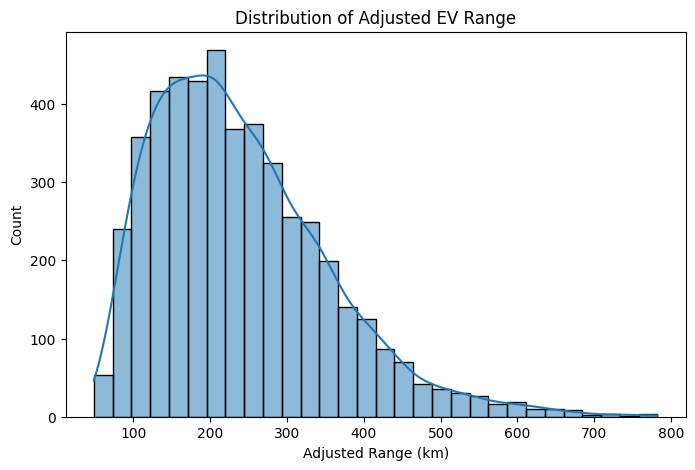

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df[target], bins=30, kde=True)

plt.title("Distribution of Adjusted EV Range")
plt.xlabel("Adjusted Range (km)")
plt.ylabel("Count")

plt.show()

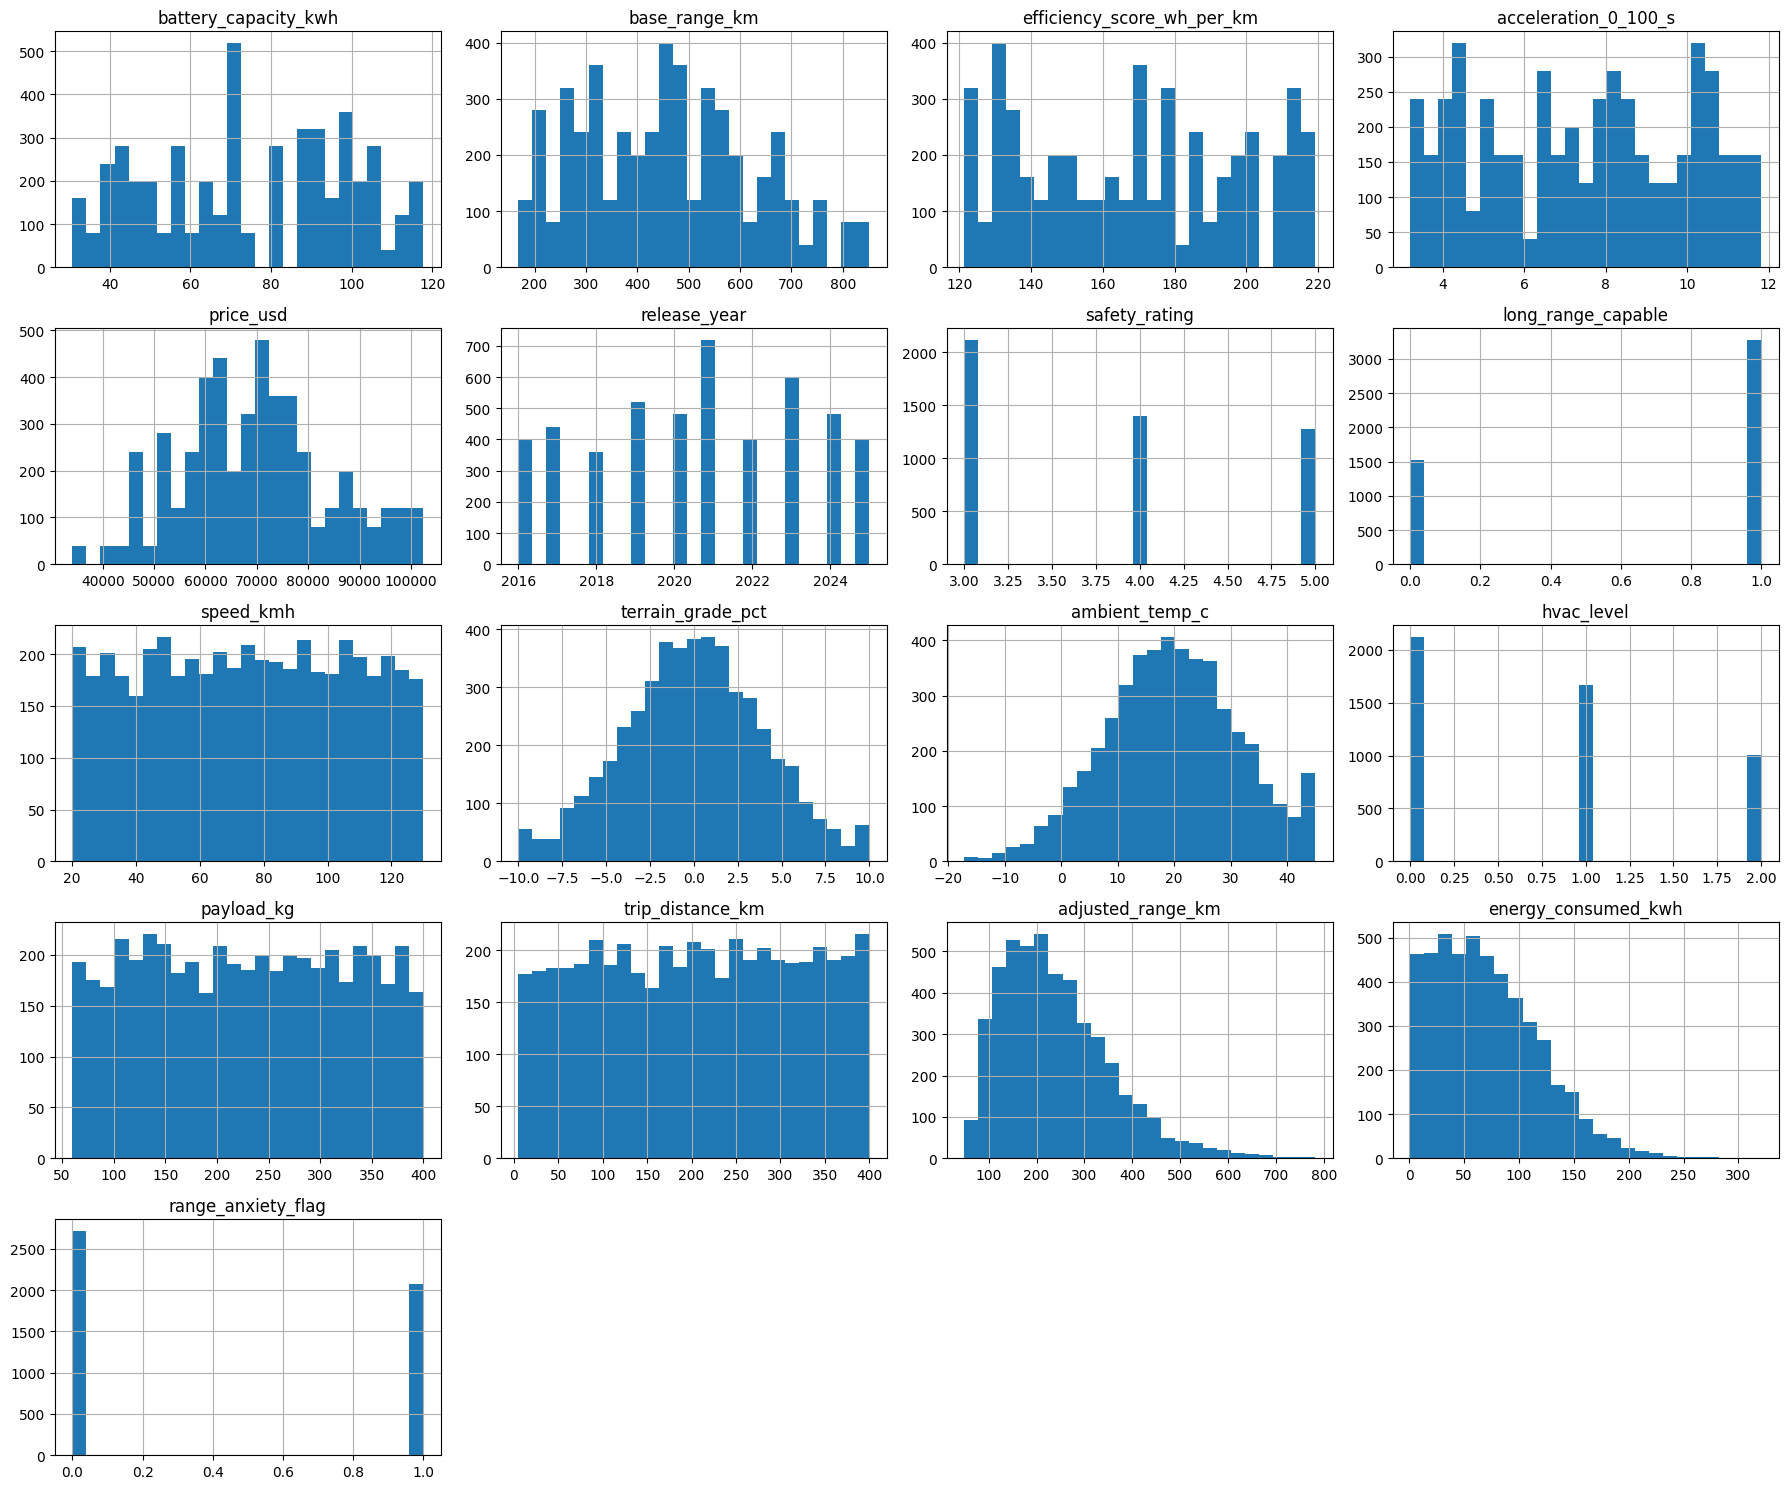

In [35]:
df[numerical_cols].hist(figsize=(18,15), bins=25)

plt.tight_layout()
plt.show()

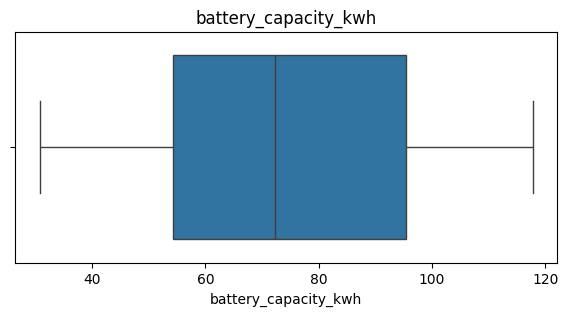

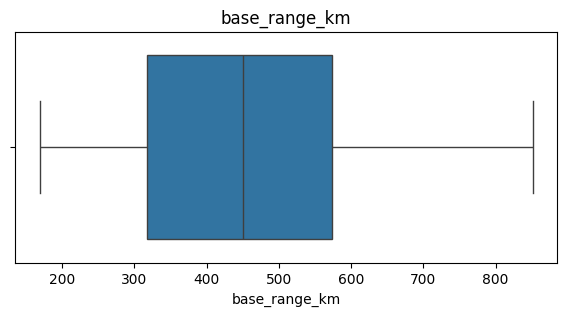

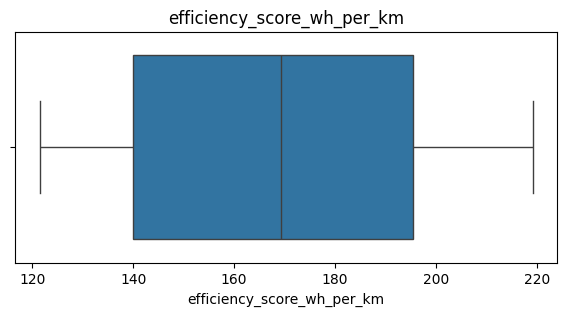

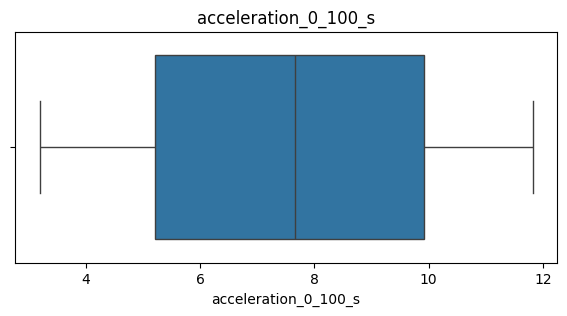

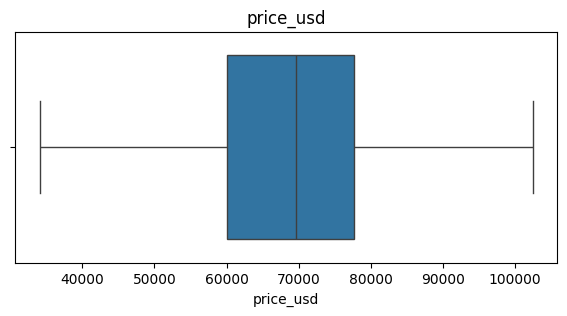

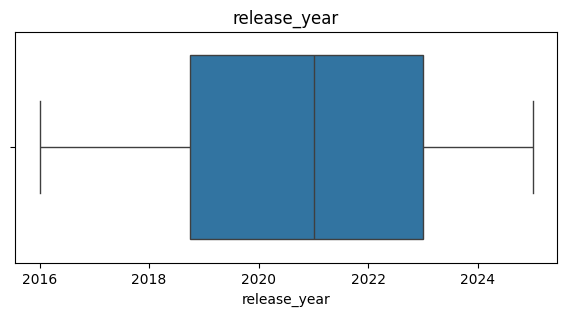

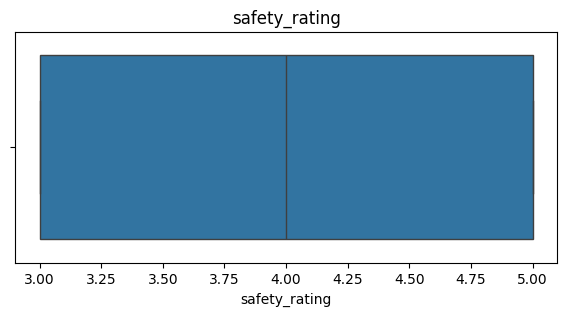

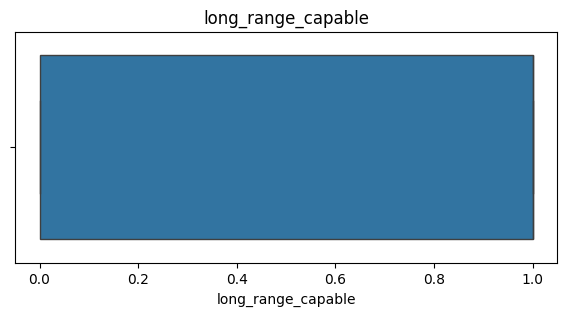

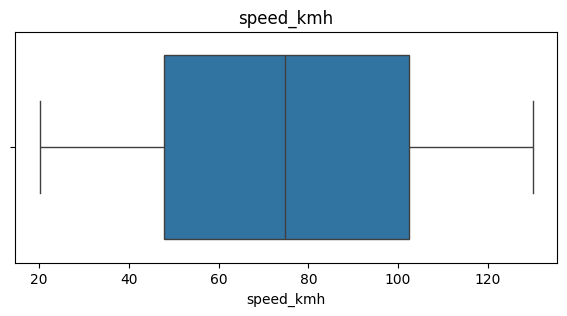

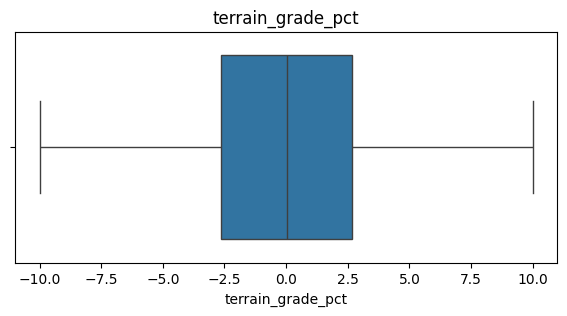

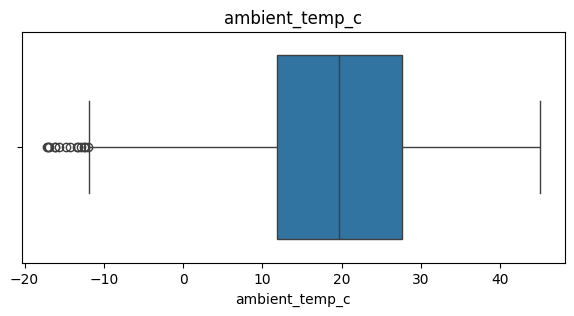

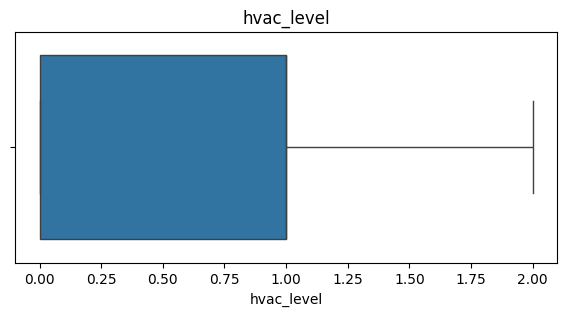

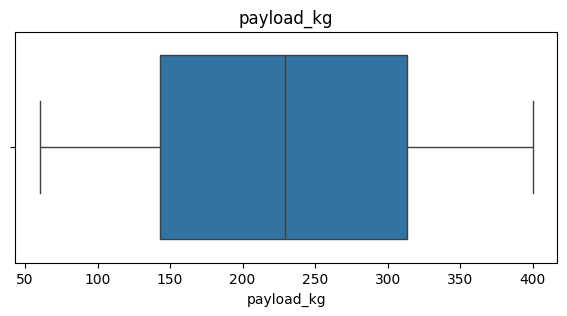

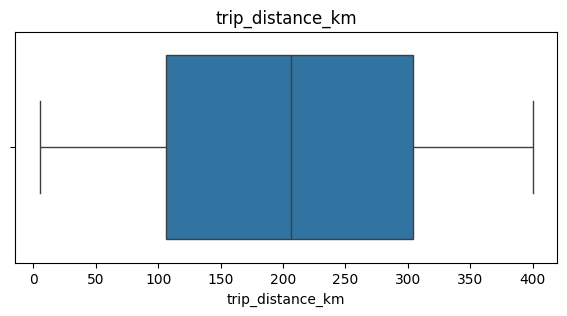

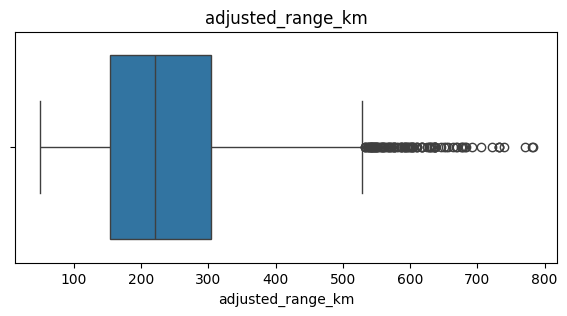

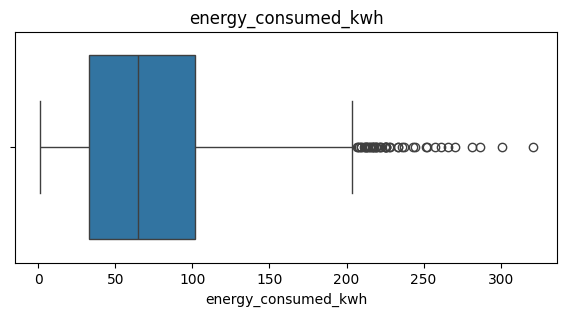

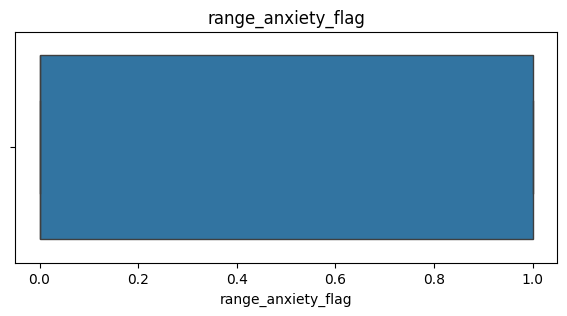

In [36]:
for col in numerical_cols:
    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col])

    plt.title(col)
    plt.show()

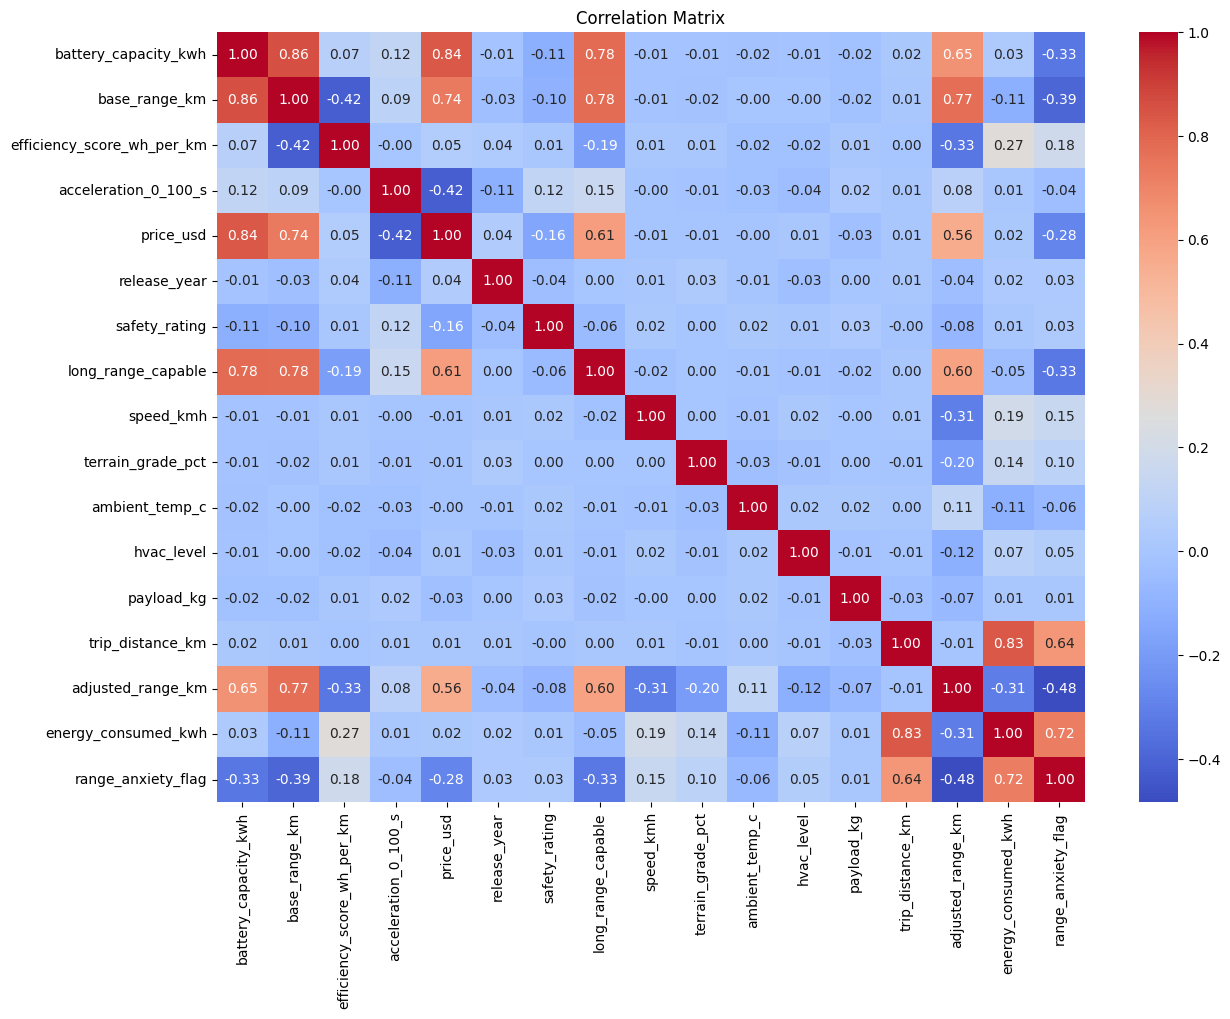

In [37]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [38]:
corr = df[numerical_cols].corr()["adjusted_range_km"].sort_values(ascending=False)

print(corr)

adjusted_range_km             1.000000
base_range_km                 0.769757
battery_capacity_kwh          0.654743
long_range_capable            0.600127
price_usd                     0.555650
ambient_temp_c                0.109998
acceleration_0_100_s          0.084177
trip_distance_km             -0.007558
release_year                 -0.039638
payload_kg                   -0.065009
safety_rating                -0.076467
hvac_level                   -0.118174
terrain_grade_pct            -0.197364
speed_kmh                    -0.306070
energy_consumed_kwh          -0.314291
efficiency_score_wh_per_km   -0.334883
range_anxiety_flag           -0.483263
Name: adjusted_range_km, dtype: float64


In [39]:
df = df.drop("vehicle_id", axis=1)

In [40]:
df = pd.get_dummies(
    df,
    columns=["drivetrain", "market_region"],
    drop_first=True
)

In [41]:
X = df.drop("adjusted_range_km", axis=1)
y = df["adjusted_range_km"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_pred_lr = lr.predict(X_test_scaled)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 33.60612080579628
RMSE: 47.09494208076432
R² Score: 0.8164910192461124


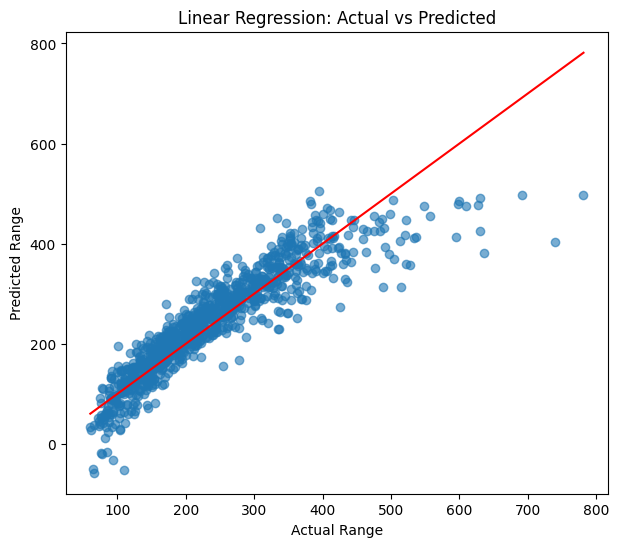

In [48]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.xlabel("Actual Range")
plt.ylabel("Predicted Range")
plt.title("Linear Regression: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

In [49]:
from sklearn.tree import DecisionTreeRegressor

In [50]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [51]:
y_pred_dt = dt.predict(X_test)

In [53]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R² Score:", r2_dt)

MAE : 25.056770833333335
RMSE: 36.50923042533216
R² Score: 0.8897155844466594


In [54]:
from sklearn.ensemble import RandomForestRegressor

In [56]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred_rf = rf.predict(X_test)

In [59]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE : 15.2699125
RMSE: 21.658058313763853
R² Score: 0.9611896261472532


In [60]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
2,Random Forest,15.269913,21.658058,0.961190
1,Decision Tree,25.056771,36.509230,0.889716
0,Linear Regression,33.606121,47.094942,0.816491


In [61]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,base_range_km,0.590676
8,speed_kmh,0.269552
10,ambient_temp_c,0.046362
9,terrain_grade_pct,0.042869
7,long_range_capable,0.011249
14,energy_consumed_kwh,0.009570
11,hvac_level,0.007454
12,payload_kg,0.006013
13,trip_distance_km,0.003404
2,efficiency_score_wh_per_km,0.002310


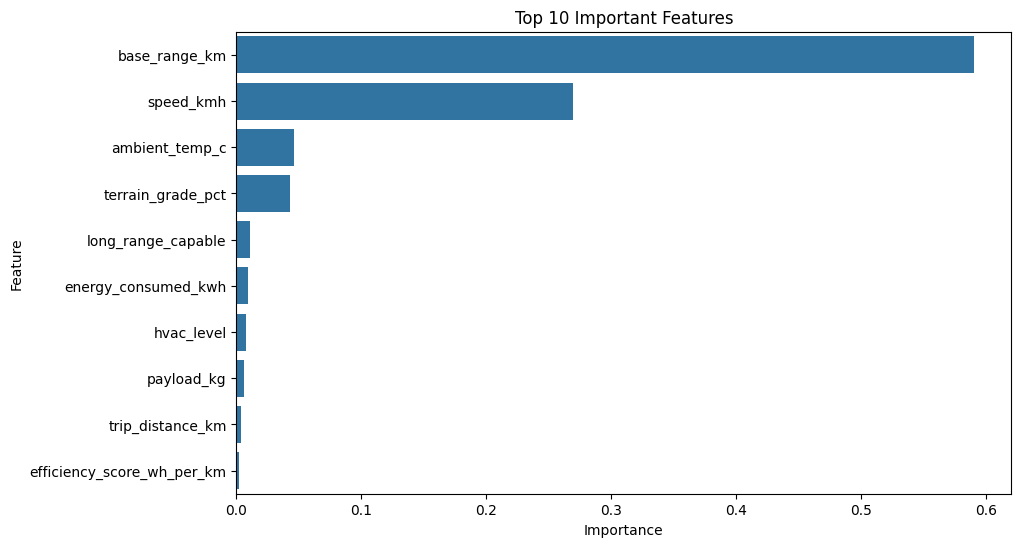

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [63]:
prediction_df = X_test.copy()

prediction_df["Actual_Range"] = y_test.values
prediction_df["Predicted_Range"] = y_pred_rf
prediction_df["Error"] = prediction_df["Actual_Range"] - prediction_df["Predicted_Range"]
prediction_df["Absolute_Error"] = abs(prediction_df["Error"])

prediction_df.head()

,battery_capacity_kwh,base_range_km,efficiency_score_wh_per_km,acceleration_0_100_s,price_usd,release_year,safety_rating,long_range_capable,speed_kmh,terrain_grade_pct,...,drivetrain_RWD,market_region_Europe,market_region_India,market_region_Middle East,market_region_North America,market_region_Oceania,Actual_Range,Predicted_Range,Error,Absolute_Error
596,69.9,390.3,179.1,5.13,73674.0,2021,5,1,120.8,2.30,...,True,True,False,False,False,False,158.3,168.9425,-10.6425,10.6425
3370,32.0,263.6,121.4,10.64,34079.0,2016,5,0,51.7,-3.78,...,False,False,True,False,False,False,255.2,232.9000,22.3000,22.3000
3048,56.4,313.5,179.9,6.42,61274.0,2018,3,0,25.5,-2.90,...,True,False,False,False,False,False,137.7,162.0885,-24.3885,24.3885
2908,106.8,807.3,132.3,5.09,94297.0,2020,3,1,22.1,-0.96,...,False,True,False,False,False,False,346.9,383.7735,-36.8735,36.8735
8,99.7,558.9,178.4,10.46,72977.0,2018,3,1,28.6,1.52,...,True,False,False,False,False,False,275.0,315.5210,-40.5210,40.5210


In [64]:
prediction_df.to_csv("EV_Range_Predictions.csv", index=False)

In [65]:
importance.to_csv("Feature_Importance.csv", index=False)

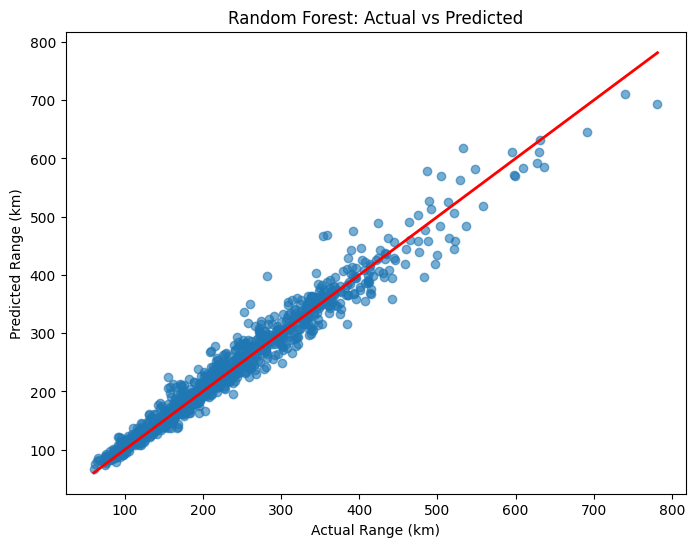

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Range (km)")
plt.ylabel("Predicted Range (km)")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

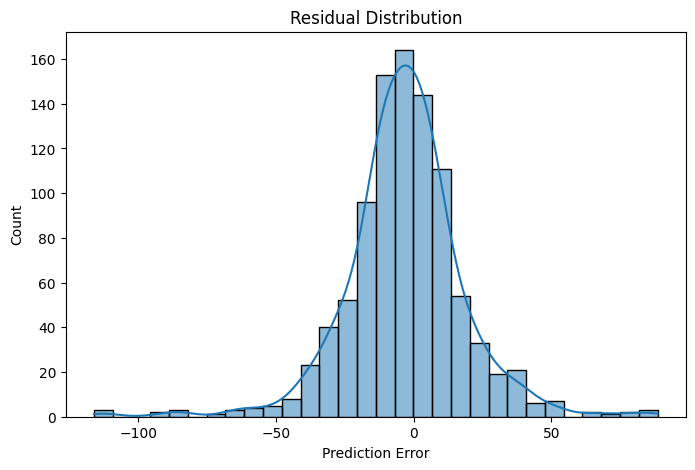

In [67]:
errors = y_test - y_pred_rf

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=30, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")

plt.show()

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9592754013074678


In [69]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 15.293661740999164
RMSE: 21.69123370759055
R2  : 0.9610706371280077
